# GRU-grid model across N and Omega
Train on `GenerateTraj/data*` and generate trajectories at seen or interpolated conditions.

In [2]:
from pathlib import Path
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt

project_root = Path.cwd().parent if Path.cwd().name == 'different_omega' else Path.cwd()
sys.path.insert(0, str(project_root))
from different_omega.dataset import MultiNOmegaNextStateDataset
from different_omega.model import ConditionedNOmegaTrajectoryGRUGrid
from different_omega.train_grid_model import load_trajectories, generate_trajectories

data_root = project_root / 'GenerateTraj'
checkpoint_path = project_root / 'different_omega' / 'different_omega_grugrid_best.pt'
n_values = [4, 6, 8, 10, 12, 14, 16]
omega_values = None  # e.g. [.61, .65, .69, .71, .75]

## Inspect available conditions

In [4]:
sz, values_n, values_omega, source_files = load_trajectories(data_root, n_values, omega_values, 5)
print('trajectories:', sz.shape)
print('N:', sorted(set(values_n.tolist())))
print('Omega/Omega_c:', sorted(set(values_omega.tolist())))

trajectories: (280, 210)
N: [4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 16.0]
Omega/Omega_c: [0.6100000143051147, 0.6299999952316284, 0.6499999761581421, 0.6700000166893005, 0.6899999976158142, 0.7099999785423279, 0.7300000190734863, 0.75]


## Train
Run this cell after choosing the data volume and hyperparameters. Missing N folders are skipped automatically.

In [8]:
from pathlib import Path
import os
import sys

print("Working directory:", Path.cwd())
print("Python executable:", sys.executable)

Working directory: /gpfs01/work/nikital/projects/deep_learning/study_trajectories_1/different_omega
Python executable: /work/nikital/conda_envs/DL26/bin/python3.12


In [10]:
%cd ..

/gpfs01/work/nikital/projects/deep_learning/study_trajectories_1


In [12]:
import subprocess
import sys

subprocess.run(
    [
        sys.executable,
        "-m",
        "different_omega.train_grid_model",
        "--data-root", "GenerateTraj",
        "--epochs", "100",
    ],
    check=True,
)

Epoch   1/100 | validation grid NLL: 4.49713
Epoch  10/100 | validation grid NLL: 3.42844
Epoch  20/100 | validation grid NLL: 3.22663
Epoch  30/100 | validation grid NLL: 3.12564
Epoch  40/100 | validation grid NLL: 3.04537
Epoch  50/100 | validation grid NLL: 3.05404
Epoch  60/100 | validation grid NLL: 2.99645
Epoch  70/100 | validation grid NLL: 2.98430
Epoch  80/100 | validation grid NLL: 2.99775
Epoch  90/100 | validation grid NLL: 2.97192
Epoch 100/100 | validation grid NLL: 2.96472
Using: cuda; saved checkpoint: /gpfs01/work/nikital/projects/deep_learning/study_trajectories_1/different_omega/different_omega_grugrid_best.pt
Training conditions: N=[4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 16.0, 18.0], Omega/Omega_c=[0.6100000143051147, 0.6299999952316284, 0.6499999761581421, 0.6700000166893005, 0.6899999976158142, 0.7099999785423279, 0.7300000190734863, 0.75]


CompletedProcess(args=['/work/nikital/conda_envs/DL26/bin/python3.12', '-m', 'different_omega.train_grid_model', '--data-root', 'GenerateTraj', '--epochs', '100'], returncode=0)

In [11]:
!python -m different_omega.train_grid_model --data-root GenerateTraj --n-values 4 6 8 10 12 14 16 --trajectories-per-condition 500 --epochs 100 --checkpoint different_omega/different_omega_grugrid_best.pt

Traceback (most recent call last):
  File "/usr/lib64/python3.9/runpy.py", line 188, in _run_module_as_main
    mod_name, mod_spec, code = _get_module_details(mod_name, _Error)
  File "/usr/lib64/python3.9/runpy.py", line 111, in _get_module_details
    __import__(pkg_name)
  File "/gpfs01/work/nikital/projects/deep_learning/study_trajectories_1/different_omega/__init__.py", line 3, in <module>
    from .dataset import MultiNOmegaNextStateDataset, stratified_split_indices
  File "/gpfs01/work/nikital/projects/deep_learning/study_trajectories_1/different_omega/dataset.py", line 6, in <module>
    import torch
ModuleNotFoundError: No module named 'torch'


## Generate at different N and Omega

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=True)
model = ConditionedNOmegaTrajectoryGRUGrid(**checkpoint['model_config']).to(device)
model.load_state_dict(checkpoint['model_state_dict'])

conditions = [(8, .61), (8, .68), (12, .71), (16, .75)]
initial_sz = torch.full((32,), -1.0)
generated = {condition: generate_trajectories(model, condition[0], condition[1], initial_sz, sz.shape[1], time_end=checkpoint['time_end'], temperature=.8) for condition in conditions}
print({condition: values.shape for condition, values in generated.items()})

{(8, 0.61): torch.Size([32, 210]), (8, 0.68): torch.Size([32, 210]), (12, 0.71): torch.Size([32, 210]), (16, 0.75): torch.Size([32, 210])}


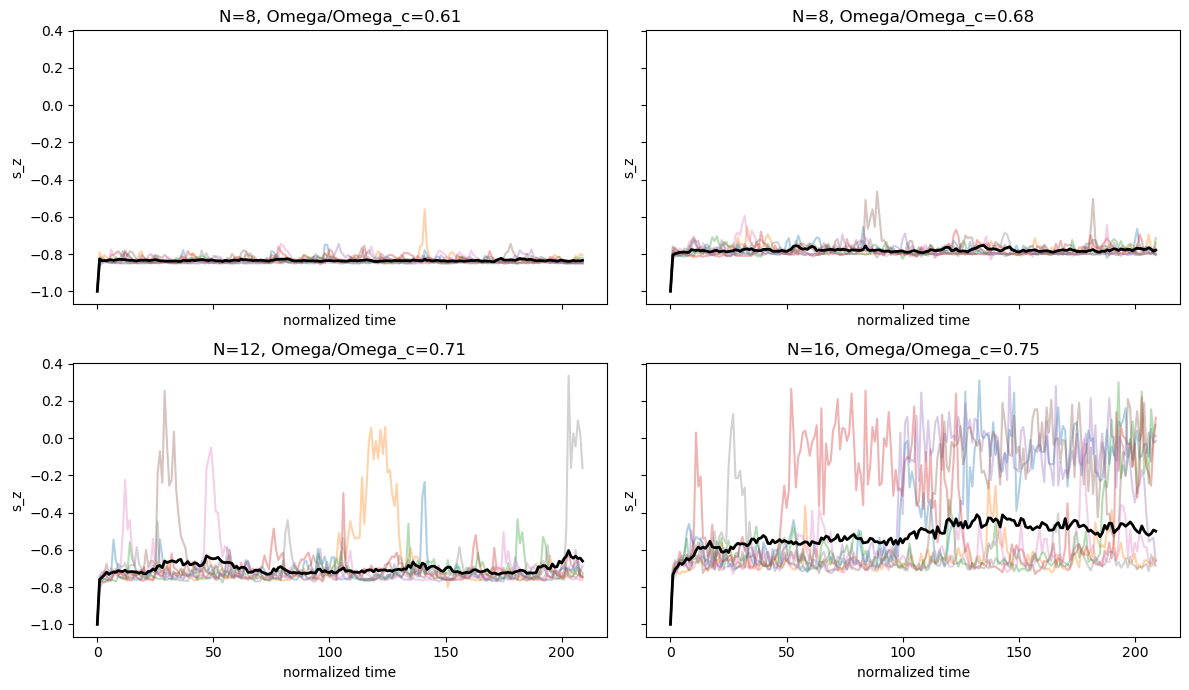

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True, sharey=True)
for axis, (condition, values) in zip(axes.flat, generated.items()):
    axis.plot(values[:8].cpu().T, alpha=.35)
    axis.plot(values.mean(0).cpu(), color='black', linewidth=2)
    axis.set_title(f'N={condition[0]}, Omega/Omega_c={condition[1]:.2f}')
    axis.set_xlabel('normalized time')
    axis.set_ylabel('s_z')
plt.tight_layout()

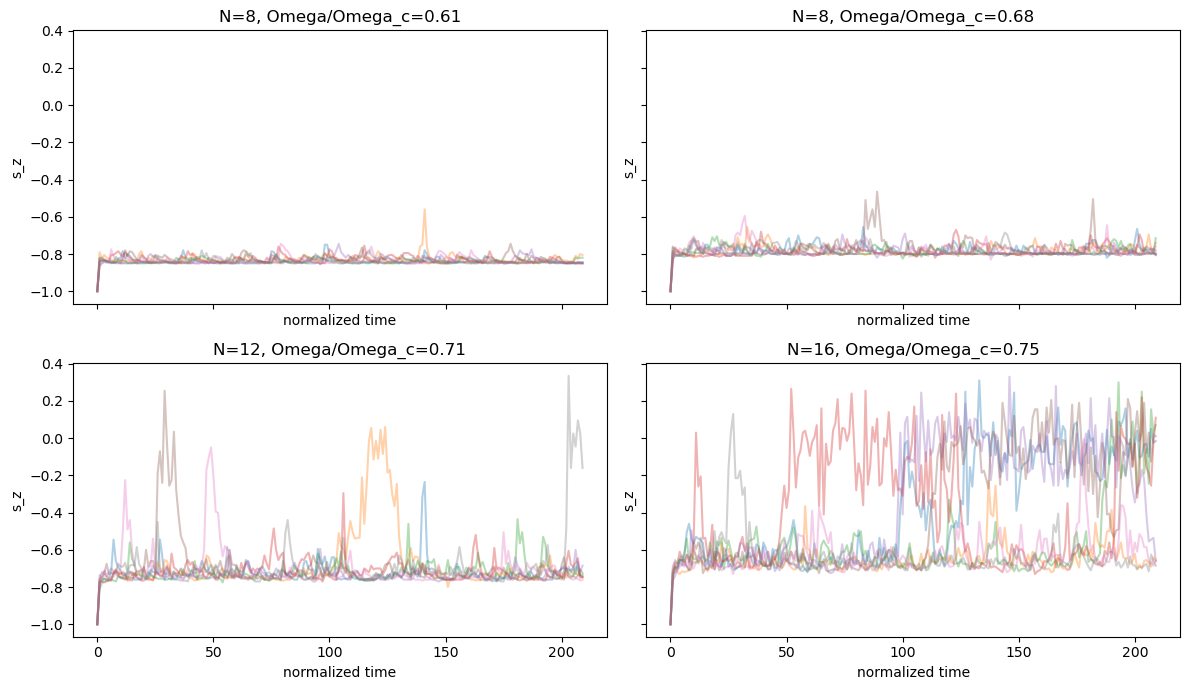

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True, sharey=True)
for axis, (condition, values) in zip(axes.flat, generated.items()):
    axis.plot(values[:8].cpu().T, alpha=.35)
    #axis.plot(values.mean(0).cpu(), color='black', linewidth=2)
    axis.set_title(f'N={condition[0]}, Omega/Omega_c={condition[1]:.2f}')
    axis.set_xlabel('normalized time')
    axis.set_ylabel('s_z')
plt.tight_layout()

In [16]:
gen_traj = generate_trajectories(model, 18, 0.71, initial_sz, sz.shape[1], time_end=checkpoint['time_end'], temperature=.8)

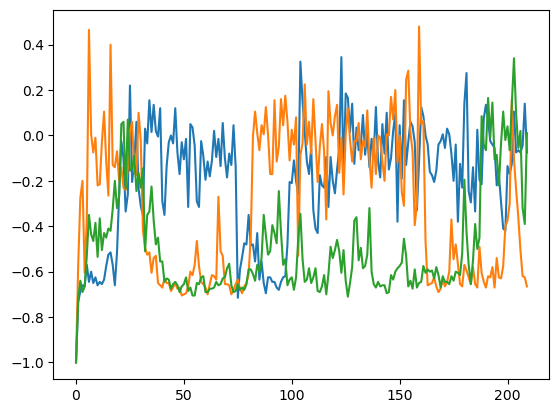

In [33]:
gen_traj = generate_trajectories(model, 18, 0.8, initial_sz, sz.shape[1], time_end=checkpoint['time_end'], temperature=.8)
plt.plot(gen_traj[:3].cpu().T)

In [7]:
def solve_sz_roots(Omega, Gamma_tilde, Delta_tilde):
    """
    Solve the cubic equation for s_z at given Omega.
    gamma is fixed to 1.
    Returns all (possibly complex) roots.
    """
    gamma = 1.0
    Omega_c = np.sqrt(Gamma_tilde**2 + 4*Delta_tilde**2) / 4

    a3 = 16 * Omega_c**2
    a2 = 16 * Omega_c**2 - 2 * gamma * Gamma_tilde
    a1 = gamma**2 - 2 * gamma * Gamma_tilde + 8 * Omega**2
    a0 = gamma**2

    coeffs = [a3, a2, a1, a0]
    roots = np.roots(coeffs)

    return roots
def physical_sz_roots(Omega, Gamma_tilde, Delta_tilde, tol=1e-8):
    roots = solve_sz_roots(Omega, Gamma_tilde, Delta_tilde)

    phys = []
    for r in roots:
        if abs(r.imag) < tol and abs(r.real) <= 1 + tol:
            phys.append(r.real)

    return phys

def scan_sz_vs_r(Gamma_tilde, Delta_tilde,
                 r_min=0.0, r_max=1.2, npts=400):
    """
    Scan physical s_z solutions as a function of r = Omega / Omega_c
    """
    Omega_c = np.sqrt(Gamma_tilde**2 + 4*Delta_tilde**2) / 4
    r_vals = np.linspace(r_min, r_max, npts)

    r_plot = []
    sz_plot = []

    for r in r_vals:
        Omega = r * Omega_c
        roots = physical_sz_roots(Omega, Gamma_tilde, Delta_tilde)
        for sz in roots:
            r_plot.append(r)
            sz_plot.append(sz)

    return np.array(r_plot), np.array(sz_plot)


N: 22
Encoded N: 1.2222222222222223
Generated range: -1.0 0.435


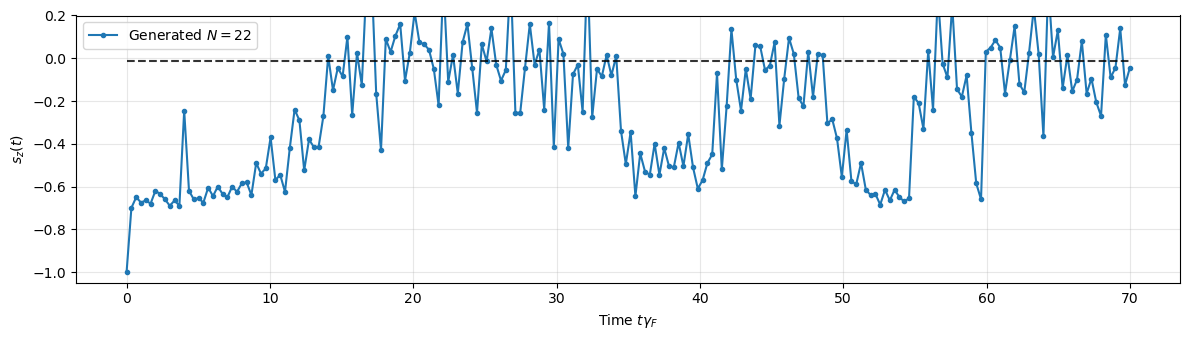

In [21]:
# Choose the particle number to generate.
N_to_generate = 22
omega = 0.8
initial_state = -1.0
random_seed = 9

#n_time_points = next(iter(trajectory_groups.values())).shape[1]

sample_generator = torch.Generator(
    device=device
).manual_seed(random_seed)

generated_trajectory = generate_trajectories(
    model,
    particle_number=N_to_generate,
    omega_ratio = omega,
    initial_sz=torch.tensor([initial_state], dtype=torch.float32),
    n_time_points=sz.shape[1],
    time_end=checkpoint['time_end'],
    temperature=1.0,
    generator=sample_generator,
).cpu().numpy()[0]

physical_time = np.linspace(0.0, 70.0, sz.shape[1])

print("N:", N_to_generate)
print("Encoded N:", N_to_generate / model.n_reference)
print(
    "Generated range:",
    generated_trajectory.min(),
    generated_trajectory.max(),
)

plt.figure(figsize=(12, 3.5))
plt.plot(
    physical_time,
    generated_trajectory,
    "-o",
    markersize=3,
    linewidth=1.5,
    label=fr"Generated $N={N_to_generate}$",
)
# --- Add vertical lines here ---
G = 10/11*(N_to_generate-1)
# 1. Call the function once and store the roots
roots = solve_sz_roots(omega*G/4, G, 0)

# 2. Filter out the complex roots. 
# We use a small tolerance (1e-10) to account for floating-point rounding errors.
# We also extract just the real part (.real) to drop the +0j component.
real_roots = [r.real for r in roots if abs(np.imag(r)) < 1e-10]

# 3. Apply your plotting logic
if len(real_roots) == 3:
    hlines = [real_roots[0], real_roots[-1]]
else:
    # If there are 1 or 2 real roots, just plot those
    hlines = real_roots
for y in hlines:
    plt.hlines(y=y,xmin = 0, xmax = 70,color = 'black', linestyle="--", linewidth=1.5, alpha=0.8)
plt.xlabel(r"Time $t\gamma_F$")
plt.ylabel(r"$s_z(t)$")
plt.ylim(model.state_min - 0.05,0.2)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()